/home/romulo/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
[I 2024-08-15 15:46:13,948] A new study created in memory with name: no-name-ea48ce9a-8eac-4c2e-a3b1-281e5e8fcef0


Using device: cpu
Loaded data dimensions: (128, 128, 1433)
hidden_size= 128
hidden_layers= 1
batch_size= 64
lr= 0.000874209909947813
lambL2= 0.0012744245338806544
lambL1= 0.012941873016575905
lambdaSNR= 0.4026151489941498
l1= 300
l2= 300
lags= 5
num_sensors= 1
num_epochs= 1
Forma do snapshot após subamostragem: (128, 128, 1433)


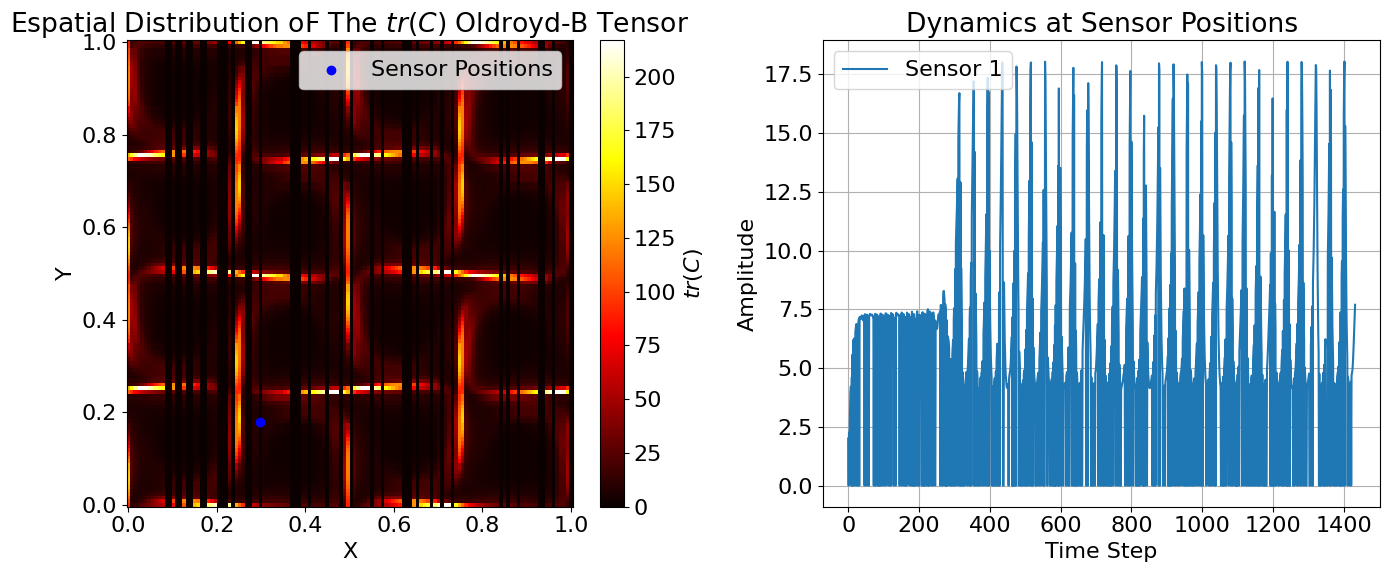

trace_A (128, 128, 1433)
trace_A_ori (128, 128, 1433)
load_X (1433, 16384)
load_X_test (1433, 16384)
1433 16384
device: cpu
Número de sensores:1


/home/romulo/.local/lib/python3.10/site-packages/numpy/lib/shape_base.py:260: ComplexWarning: Casting complex values to real discards the imaginary part
  arr[_make_along_axis_idx(arr_shape, indices, axis)] = values
/home/romulo/Documentos/cs-shred-clean/models.py:153: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at ../aten/src/ATen/native/Copy.cpp:300.)
  combined_recovered_signal_expanded = combined_recovered_signal_expanded.float()
/home/romulo/.local/lib/python3.10/site-packages/numpy/lib/shape_base.py:260: ComplexWarning: Casting complex values to real discards the imaginary part
  arr[_make_along_axis_idx(arr_shape, indices, axis)] = values


test_recons shape: (142, 16384)
test_ground_truth_test shape: (142, 16384)


[I 2024-08-15 15:46:33,376] Trial 0 finished with value: 2.79160475730896 and parameters: {'hidden_size': 128, 'hidden_layers': 1, 'batch_size': 64, 'lr': 0.000874209909947813, 'lambL2': 0.0012744245338806544, 'lambL1': 0.012941873016575905, 'lambdaSNR': 0.4026151489941498, 'l1': 300, 'l2': 300, 'lags': 5, 'num_sensors': 1, 'num_epochs': 1}. Best is trial 0 with value: 2.79160475730896.


Normalized Error: 2.7916048
SSIM: -0.09694630601985911
Loaded data dimensions: (128, 128, 1433)
hidden_size= 64
hidden_layers= 1
batch_size= 128
lr= 0.004503449305346686
lambL2= 0.0048439504396279994
lambL1= 0.7415349557895838
lambdaSNR= 0.08930780271914258
l1= 300
l2= 400
lags= 5
num_sensors= 1
num_epochs= 1
Forma do snapshot após subamostragem: (128, 128, 1433)


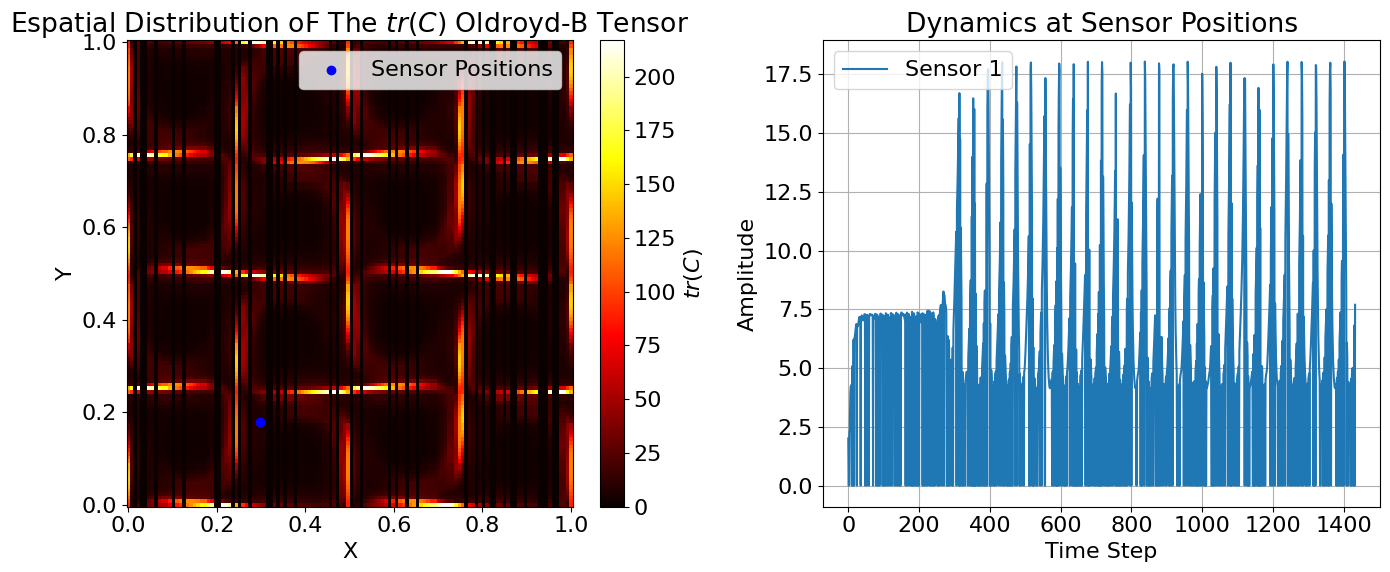

trace_A (128, 128, 1433)
trace_A_ori (128, 128, 1433)
load_X (1433, 16384)
load_X_test (1433, 16384)
1433 16384
device: cpu
Número de sensores:1


/home/romulo/.local/lib/python3.10/site-packages/numpy/lib/shape_base.py:260: ComplexWarning: Casting complex values to real discards the imaginary part
  arr[_make_along_axis_idx(arr_shape, indices, axis)] = values
/home/romulo/.local/lib/python3.10/site-packages/numpy/lib/shape_base.py:260: ComplexWarning: Casting complex values to real discards the imaginary part
  arr[_make_along_axis_idx(arr_shape, indices, axis)] = values


test_recons shape: (142, 16384)
test_ground_truth_test shape: (142, 16384)


[I 2024-08-15 15:46:47,540] Trial 1 finished with value: 2.5593512058258057 and parameters: {'hidden_size': 64, 'hidden_layers': 1, 'batch_size': 128, 'lr': 0.004503449305346686, 'lambL2': 0.0048439504396279994, 'lambL1': 0.7415349557895838, 'lambdaSNR': 0.08930780271914258, 'l1': 300, 'l2': 400, 'lags': 5, 'num_sensors': 1, 'num_epochs': 1}. Best is trial 1 with value: 2.5593512058258057.


Normalized Error: 2.5593512
SSIM: -0.12457108756950384
Best trial:
Best trial parameters and metrics saved to 'best_trial_params.json'


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
import optuna
import json
import os

import models
from processdata import TimeSeriesDataset

# Verifica a disponibilidade de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Função para carregar dados de um arquivo .npy
def load_data(npy_file_path):
    data_array = np.load(npy_file_path, allow_pickle=True)
    data_array = data_array.item()
    data_array = data_array["trace_A"].copy()
    print("Loaded data dimensions:", data_array.shape)
    return data_array


# Visualização dos dados 2D ou 3D
def visualize_data(matrix, subsampled):
    plt.imshow(matrix[-1, :, :], cmap="Spectral", origin="lower")
    plt.colorbar()
    plt.title("Last Temporal Slice")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    plt.imshow(subsampled[:, :, -1], cmap="Spectral", origin="lower")
    plt.colorbar()
    plt.title("Last Temporal Slice (Subsampled)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()



def subsample(snapshot, percent_subsample):
    """
    Realiza a subamostragem de um snapshot tridimensional, preservando regras específicas.
    
    Parâmetros de entrada:
    snapshot: numpy array, snapshot tridimensional
    percent_subsample: float, percentual de subamostragem desejado
    
    Retorna:
    snapshot_subsampled: numpy array, snapshot subamostrado
    """
    num_cols_subsample = int(snapshot.shape[1] * percent_subsample)
    snapshot_subsampled = snapshot.copy()

    for i in range(snapshot.shape[2]):
        random_indices = np.random.choice(
            snapshot.shape[1], size=num_cols_subsample, replace=False
        )

        # Garante que os extremos da lista não sejam subamostrados e não há lacunas maiores que 3 índices
        random_indices = sorted(random_indices)
        diff_indices = np.diff(random_indices)
        for j in range(len(random_indices) - 1):
            if diff_indices[j] > 4:
                random_indices[j + 1] = random_indices[j] + 3

        snapshot_subsampled[:, random_indices, i] = 0

    return snapshot_subsampled


# Configuração dos sensores
def plot_dynamics_at_sensors(
    trace_A, num_sensors, locations="c", show_plot=False, seed=101
):
    np.random.seed(seed)

    dim_x, dim_y, dim_t = trace_A.shape

    print("Forma do snapshot após subamostragem:", trace_A.shape)

    if locations == "a":
        central_x = 0.5
        central_y = 0.5
        sensor_locations = np.random.choice(dim_x * dim_y, num_sensors, replace=False)
        sensor_positions_x = sensor_locations % dim_x / dim_x
        sensor_positions_y = sensor_locations // dim_y / dim_y

        sensor_positions_x = np.append(sensor_positions_x, central_x)
        sensor_positions_y = np.append(sensor_positions_y, central_y)

    elif locations == "b":
        sensor_positions_x = [0.5]
        sensor_positions_y = [0.5]

    else:
        sensor_locations = np.random.choice(dim_x * dim_y, num_sensors, replace=False)
        sensor_positions_x = sensor_locations % dim_x / dim_x
        sensor_positions_y = sensor_locations // dim_y / dim_y

    # sensor_locations = np.random.choice(dim_x * dim_y, num_sensors, replace=False)
    # sensor_positions_x = sensor_locations % dim_x / dim_x
    # sensor_positions_y = sensor_locations // dim_y / dim_y


    sensor_temperature_history = []
    for t in range(dim_t):
        sensor_temperatures = [
            trace_A[int(dim_x * x), int(dim_y * y), t]
            for x, y in zip(sensor_positions_x, sensor_positions_y)
        ]
        sensor_temperature_history.append(sensor_temperatures)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    x = np.linspace(0, 1, int(dim_x))
    y = np.linspace(0, 1, int(dim_y))
    X, Y = np.meshgrid(x, y)

    cmap = ax1.pcolormesh(X, Y, trace_A[:, :, -1].real, shading="auto", cmap="hot")
    fig.colorbar(cmap, ax=ax1, label=r"$tr(C)$")
    ax1.set_title("Espatial Distribution oF The $tr(C)$ Oldroyd-B Tensor")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")

    ax1.scatter(
        sensor_positions_x, sensor_positions_y, color="blue", label="Sensor Positions"
    )
    ax1.legend()

    sensor_temperature_history = np.array(sensor_temperature_history)
    for i, sensor_data in enumerate(sensor_temperature_history.T):
        ax2.plot(range(dim_t), sensor_data, label=f"Sensor {i+1}")

    ax2.set_xlabel("Time Step")
    ax2.set_ylabel("Amplitude")
    ax2.set_title("Dynamics at Sensor Positions")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return sensor_locations, sensor_positions_x, sensor_positions_y




# Treinamento e validação do modelo
def train_and_validate_model(
    type_model,
    model,
    train_dataset,
    valid_dataset,
    num_epochs,
    batch_size,
    lr,
    lambL2,
    lambL1,
    lambdaSNR,
    verbose,
    patience,
):
    if type_model == "CS-SHRED":
        train_error, validation_errors = models.fit_csshred_model(
            model,
            train_dataset,
            valid_dataset,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            lambL2=lambL2,
            lambL1=lambL1,
            lambdaSNR=lambdaSNR,
            verbose=verbose,
            patience=patience,
        )
        return train_error, validation_errors
    else:
        validation_errors = models.fit(
            model,
            train_dataset,
            valid_dataset,
            batch_size=64,
            num_epochs=1000,
            lr=1e-3,
            verbose=True,
            patience=5,
        )
        return validation_errors



def evaluate_model(model, test_dataset, sc, sc_test):
    test_recons = sc.inverse_transform(model(test_dataset.X).detach().cpu().numpy())
    test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
    test_ground_truth_test = sc_test.inverse_transform(test_dataset.Y.detach().cpu().numpy())
    
    error_norm = np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    # Calcular o SSIM
    ssim_score = ssim(test_ground_truth_test, test_recons, data_range=test_recons.max() - test_recons.min())
    
    print("Normalized Error:", error_norm)
    print("SSIM:", ssim_score)
    
    return test_recons, test_ground_truth, test_ground_truth_test, error_norm, ssim_score


def objective(trial):
    # Caminho do arquivo .npy
    npy_file_path = r"/home/romulo/migoogledrive/shred-jan/pyshred/Data/16_roll7_Re1_Wi3.5_beta0.6666/fields.npy"
    # Criação do diretório para armazenar os resultados
    results_dir = r"/home/romulo/Documentos/cs-shred-clean/results/csshred/seismic"
    os.makedirs(results_dir, exist_ok=True)

    # Carregamento dos dados
    matrix = load_data(npy_file_path)

    model_type = 'CSSHRED'

    # Parâmetros
    percent_subsample = 0.3
    seed = 915

    hidden_size = trial.suggest_categorical("hidden_size", [64, 128])
    hidden_layers = trial.suggest_categorical("hidden_layers", [1])
    batch_size = trial.suggest_categorical("batch_size", [64, 128])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    lambL2 = trial.suggest_float("lambL2", 1e-3, 1e0, log=True)
    lambL1 = trial.suggest_float("lambL1", 1e-3, 1e0, log=True)
    lambdaSNR = trial.suggest_float("lambdaSNR", 1e-3, 1e0, log=True)
    l1 = trial.suggest_categorical("l1", [300, 400])
    l2 = trial.suggest_categorical("l2", [300, 400])
    lags = trial.suggest_categorical("lags", [5])
    num_sensors = trial.suggest_categorical("num_sensors", [1])
    num_epochs = trial.suggest_int("num_epochs", 1, 2)  

    print("hidden_size=", hidden_size)
    print("hidden_layers=", hidden_layers)
    print("batch_size=", batch_size)
    print("lr=", lr)
    print("lambL2=", lambL2)
    print("lambL1=", lambL1)
    print("lambdaSNR=", lambdaSNR)
    print("l1=", l1)
    print("l2=", l2)
    print("lags=", lags)
    print("num_sensors=", num_sensors)
    print("num_epochs=", num_epochs)  

    # Atualize as variáveis globais ou crie novos dados com os novos lags
    global all_data_in, train_data_in, valid_data_in, test_data_in
    global train_data_out, valid_data_out, test_data_out, train_dataset, valid_dataset, test_dataset

    # Subamostragem e visualização dos dados
    snapshot = matrix.copy()
    snapshot = subsample(snapshot, percent_subsample)
    sensor_locations, sensor_positions_x, sensor_positions_y = plot_dynamics_at_sensors(
        snapshot, num_sensors, locations="c", show_plot=True, seed=seed
    )

    trace_A = snapshot.copy()
    trace_A_ori = snapshot.copy()

    print("trace_A", trace_A.shape)
    print("trace_A_ori", trace_A_ori.shape)

    dim_x, dim_y, dim_t = trace_A.shape
    train_size = int(0.7 * trace_A.shape[2])
    val_size = int(0.2 * trace_A.shape[2])
    test_size = int(0.1 * trace_A.shape[2])

    load_X = trace_A.reshape(dim_x * dim_y, dim_t).T
    load_X_test = trace_A_ori.reshape(dim_x * dim_y, dim_t).T

    print("load_X", load_X.shape)
    print("load_X_test", load_X_test.shape)

    n = load_X.shape[0]
    m = load_X.shape[1]
    print(n, m)

    if n - lags <= 0:
        raise ValueError("Invalid lags: exceeds data length.")

    total_size = train_size + val_size + test_size
    if total_size > n - lags:
        train_size = (train_size * (n - lags)) // total_size
        val_size = (val_size * (n - lags)) // total_size
        test_size = (test_size * (n - lags)) // total_size

    train_indices = np.random.choice(n - lags, size=train_size, replace=False)
    mask = np.ones(n - lags)
    mask[train_indices] = 0
    valid_test_indices = np.arange(0, n - lags)[np.where(mask != 0)[0]]

    valid_indices = valid_test_indices[:val_size]
    test_indices = valid_test_indices[val_size : val_size + test_size]

    sc = MinMaxScaler()
    sc = sc.fit(load_X[train_indices])
    transformed_X = sc.transform(load_X)

    sc_test = sc.fit(load_X_test[train_indices])
    transformed_X_test = sc_test.transform(load_X_test)

    all_data_in = np.zeros((n - lags, lags, num_sensors))
    all_data_in_test = np.zeros((n - lags, lags, num_sensors))
    for i in range(n - lags):
        for j, loc in enumerate(sensor_locations):
            all_data_in[i, :, j] = transformed_X[i : i + lags, loc]
            all_data_in_test[i, :, j] = transformed_X_test[i : i + lags, loc]

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device:", device)
    print("Número de sensores:{}".format(num_sensors))

    train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(
        device
    )
    valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(
        device
    )
    test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(
        device
    )
    test_data_in_test = torch.tensor(
        all_data_in_test[test_indices], dtype=torch.float32
    ).to(device)

    train_data_out = torch.tensor(
        transformed_X[train_indices + lags - 1], dtype=torch.float32
    ).to(device)
    valid_data_out = torch.tensor(
        transformed_X[valid_indices + lags - 1], dtype=torch.float32
    ).to(device)
    test_data_out = torch.tensor(
        transformed_X[test_indices + lags - 1], dtype=torch.float32
    ).to(device)
    test_data_out_test = torch.tensor(
        transformed_X_test[test_indices + lags - 1], dtype=torch.float32
    ).to(device)

    train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
    valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
    test_dataset = TimeSeriesDataset(test_data_in, test_data_out)
    test_dataset_test = TimeSeriesDataset(test_data_in_test, test_data_out_test)

    if model_type == 'CSSHRED':
        model = models.CSSHRED(
            num_sensors,
            m,
            hidden_size=hidden_size,
            hidden_layers=hidden_layers,
            l1=l1,
            l2=l2,
            dropout=0.0,
            l1_tol=0.005,
            opt_tol=1e-4, 
            ls_tol=1e-4,
            verbosity=0,
            show_plot=False,
        ).to(device)

        train_error, validation_errors = models.fit_csshred_model(
            model,
            train_dataset,
            valid_dataset,
            batch_size=batch_size,
            num_epochs=num_epochs,  # Incluindo num_epochs
            lr=lr,
            lambL2=lambL2,
            lambL1=lambL1,
            lambdaSNR=lambdaSNR,
            verbose=False,
            patience=15,
        )
    else:
        model = models.SHRED(  # 64
            num_sensors,
            m,
            hidden_size=hidden_size,
            hidden_layers=hidden_layers,
            l1=l1,
            l2=l2,
            dropout=0.0,
        ).to(device)
        validation_errors = models.fit(
            model,
            train_dataset,
            valid_dataset,
            num_epochs=num_epochs,
            batch_size=batch_size,
            lr=lr,
            verbose=False,
            patience=15,
        )
    
    test_recons = sc.inverse_transform(model(test_dataset.X).detach().cpu().numpy())
    test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
    test_ground_truth_test = sc_test.inverse_transform(
        test_dataset_test.Y.detach().cpu().numpy()
    )
    print("test_recons shape:", test_recons.shape)
    print("test_ground_truth_test shape:", test_ground_truth_test.shape)


    
    # Convertendo valores para tipos serializáveis antes de salvar
    validation_errors = [float(val) for val in validation_errors]

    # ssim_score = calculate_ssim(test_recons, test_ground_truth_test)  

    test_recons, test_ground_truth, test_ground_truth_test, error_norm, ssim_score = evaluate_model(model, test_dataset, sc, sc_test)

    with open(os.path.join(results_dir, f"{trial.number}_results.json"), "w") as f:
        results = {
            "trial_number": trial.number,
            "hidden_size": hidden_size,
            "hidden_layers": hidden_layers,
            "batch_size": batch_size,
            "lr": float(lr),
            "lambL2": float(lambL2),
            "lambL1": float(lambL1),
            "lambdaSNR": float(lambdaSNR),
            "l1": l1,
            "l2": l2,
            "lags": lags,
            "num_sensors": num_sensors,
            "num_epochs": num_epochs,  
            "error_norm": float(error_norm),
            "validation_errors": np.mean(validation_errors),           
            "error_norm": float(error_norm),
            "ssim_score": float(ssim_score),
        }
        json.dump(results, f, indent=4)

    return float(error_norm)


# Configuração do estudo do Optuna old
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=2)

# Salvando os resultados do estudo
results_dir = r"/home/romulo/Documentos/cs-shred-clean/results/csshred/seismic"
os.makedirs(results_dir, exist_ok=True)

# Extrair e imprimir o melhor ensaio
print("Best trial:")
trial = study.best_trial

# Obter os parâmetros do melhor ensaio
best_params = {
    "trial_number": trial.number,
    "hidden_size": trial.params.get("hidden_size"),
    "hidden_layers": trial.params.get("hidden_layers"),
    "batch_size": trial.params.get("batch_size"),
    "lr": float(trial.params.get("lr")),
    "lambL2": float(trial.params.get("lambL2")),
    "lambL1": float(trial.params.get("lambL1")),
    "lambdaSNR": float(trial.params.get("lambdaSNR")),
    "l1": trial.params.get("l1"),
    "l2": trial.params.get("l2"),
    "lags": trial.params.get("lags"),
    "num_sensors": trial.params.get("num_sensors"),
    "num_epochs": trial.params.get("num_epochs"),
}

# Adicionar os resultados das métricas
results_file = os.path.join(results_dir, f"{trial.number}_results.json")
with open(results_file, "r") as f:
    results = json.load(f)

best_params.update({
    "error_norm": results.get("error_norm"),
    "ssim_score": results.get("ssim_score"),
})

# Salvar os parâmetros do melhor ensaio em um arquivo JSON
with open(os.path.join(results_dir, "best_trial_params.json"), "w") as f:
    json.dump(best_params, f, indent=4)

print("Best trial parameters and metrics saved to 'best_trial_params.json'")

